In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install yfinance
!pip install scikit-learn
import yfinance as yf

In [3]:
df = yf.download("DBK.DE", start="2025-08-14", end="2026-08-14")

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head(30)

Price,Close,High,Low,Open,Volume
Ticker,DBK.DE,DBK.DE,DBK.DE,DBK.DE,DBK.DE
Date,,,,,
2025-08-14,30.318485,30.376374,29.778204,29.840916,4456875
2025-08-15,30.144825,30.665810,30.111056,30.564508,5486989
2025-08-18,30.308840,30.308840,29.811972,30.135178,4406852
2025-08-19,30.419790,30.646514,30.308840,30.390846,3282979
2025-08-20,30.173767,30.357077,29.898802,30.231654,5416344
2025-08-21,30.448732,30.588627,30.135177,30.197887,4563207
2025-08-22,30.583803,30.685106,30.361900,30.419789,3349356
2025-08-25,30.689930,30.955247,30.482500,30.487325,3516743


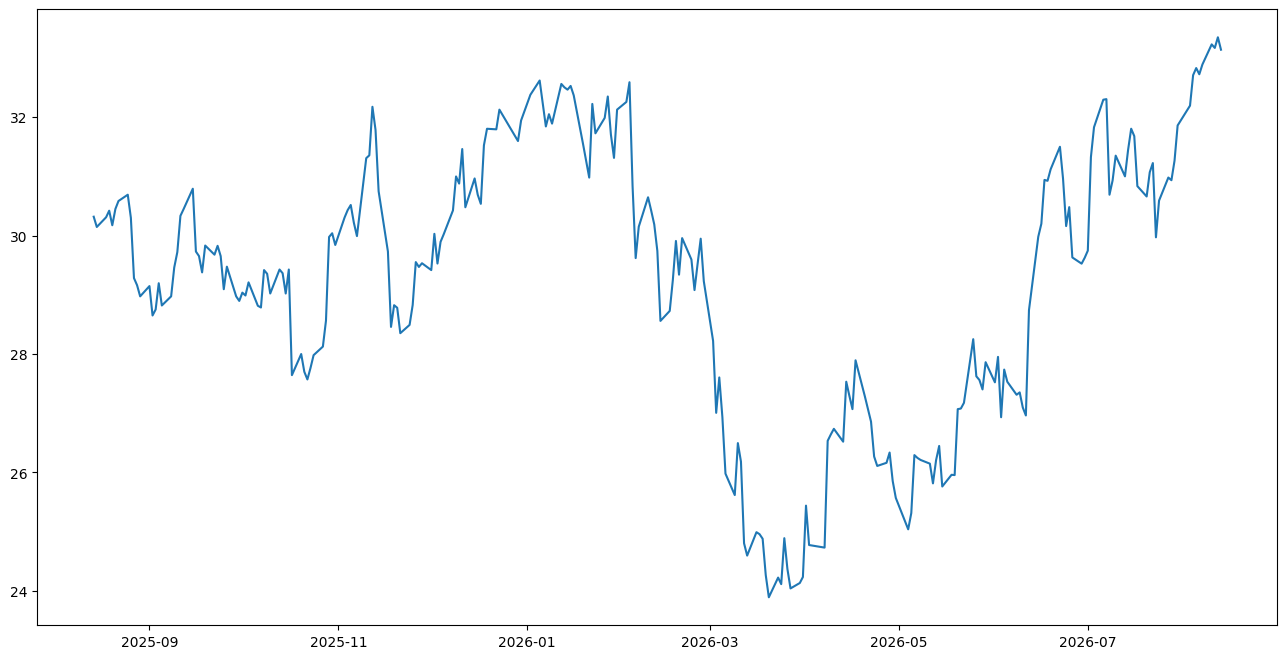

In [5]:
plt.figure(figsize=(16,8))
plt.plot (df['Close'], label='Closing')

Classification : Buy [+1] or Sell [-1] the Stock

In [6]:
df['Open - Close'] = df['Open'] - df['Close']
df['High - Low'] = df['High'] - df['Low']
df = df.dropna()

Input features to predict whether the client should buy or sell the stock

In [7]:
X = df[['Open - Close', 'High - Low']]
X.head()

Price,Open - Close,High - Low
Ticker,,
Date,,
2025-08-14,-0.477569,0.598170
2025-08-15,0.419683,0.554754
2025-08-18,-0.173662,0.496867
2025-08-19,-0.028944,0.337675
2025-08-20,0.057887,0.458275


The Intention is to store +1 for the buy signal and -1 for the sell signal. The target variable is 'Y' for the classification task

In [8]:
Y = np.where(df['Close']. shift(-1)>df['Close'],1,-1) #the shift function shifts the column up or down
#we collect the close value of the next date and if it's greater than the value of the current date
#means the next day the stock will become expensive >> label +1 
# -1 otherwise

In [9]:
Y

array([[-1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [ 1],
       [ 1],
       [ 1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [ 1],
       [ 1],
       [ 1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [ 1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [ 1],
       [ 1],
       [-1],
       [-1],
       [-1],
       [-1],
       [ 1],
       [-1],
       [-1],
       [ 1],
       [ 1],
       [ 1],
       [-1],
       [ 1],
       [-1],

### Splitting the data into training and testing

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=44)

## Implementation of the KNN Classifier

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

#using gridsearch to find the best parameter
params = {'n_neighbors': [2,3,4,5,6,7,8, 9, 10, 11, 12, 13, 14, 15]}
knn = neighbors.KNeighborsClassifier()
model = GridSearchCV(knn, params, cv=5) #Grid search CV finds us the optimal value of K;
# the value of K depends on the dataset

#y_train = y_train.ravel() #to flatten the values
#y_test = y_test.ravel()

# we fit the model on the training data
model.fit(X_train, y_train)

# Accuracy Score
accuracy_train = accuracy_score(y_train, model. predict(X_train))
accuracy_test = accuracy_score(y_test, model.predict(X_test))

print('Train_data Accuracy: %.2f' %accuracy_train) 
print('Test_data Accuracy: %.2f' %accuracy_test)

Train_data Accuracy: 0.61
Test_data Accuracy: 0.51


In [14]:
predictions_classification = model.predict(X_test)

In [18]:
actual_predicted_data = pd.DataFrame({'Actual Class' :y_test, 'Predicted Class':predictions_classification})

In [19]:
actual_predicted_data.head(10)

,Actual Class,Predicted Class
0,-1,1
1,1,1
2,1,-1
3,-1,-1
4,-1,-1
5,-1,1
6,1,1
7,-1,1
8,1,1
9,-1,1


Implementation of KNN Regression

In [25]:
from sklearn.neighbors import KNeighborsRegressor 
from sklearn import neighbors

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, Y, test_size=0.25, random_state=44)

#using gridsearch to find the best parameter
params = {'n_neighbors': [2,3,4,5,6, 7, 8,9,10, 11, 12, 13, 14, 15]}
knn_reg = neighbors.KNeighborsRegressor()
model_reg = GridSearchCV(knn_reg, params, cv=5)

#fitting the model and make predictions 
model_reg.fit(X_train_reg,y_train_reg)
predictions = model_reg.predict(X_test_reg)

In [26]:
print(predictions)

[[ 0.14285714]
 [ 0.42857143]
 [ 0.        ]
 [-0.14285714]
 [-0.14285714]
 [ 0.14285714]
 [ 0.        ]
 [ 0.        ]
 [ 0.28571429]
 [ 0.        ]
 [-0.14285714]
 [ 0.        ]
 [ 0.28571429]
 [ 0.14285714]
 [ 0.        ]
 [-0.28571429]
 [ 0.28571429]
 [ 0.        ]
 [-0.14285714]
 [-0.14285714]
 [ 0.28571429]
 [ 0.28571429]
 [ 0.28571429]
 [ 0.42857143]
 [ 0.42857143]
 [-0.14285714]
 [ 0.42857143]
 [-0.57142857]
 [-0.14285714]
 [-0.14285714]
 [ 0.14285714]
 [-0.57142857]
 [-0.14285714]
 [ 0.42857143]
 [ 0.28571429]
 [ 0.14285714]
 [-0.28571429]
 [-0.57142857]
 [ 0.14285714]
 [-0.14285714]
 [-0.14285714]
 [ 0.28571429]
 [-0.57142857]
 [-0.57142857]
 [ 0.28571429]
 [ 0.42857143]
 [-0.14285714]
 [ 0.42857143]
 [ 0.        ]
 [ 0.42857143]
 [-0.42857143]
 [ 0.28571429]
 [ 0.        ]
 [-0.57142857]
 [ 0.57142857]
 [ 0.14285714]
 [-0.14285714]
 [-0.28571429]
 [ 0.14285714]
 [ 0.57142857]
 [-0.28571429]
 [-0.42857143]
 [-0.28571429]]


In [28]:
#root mean square error
rms=np.sqrt(np.mean(np.power((np.array(y_test)-np.array(predictions)),2)))
rms

1.048031252650784

In [39]:
valid = pd.DataFrame({
    'Actual Close': y_test_reg.ravel(),
    'Predicted Close value': predictions.ravel()
},index=X_test_reg.index)

In [40]:
valid.head(10)

,Actual Close,Predicted Close value
Date,,
2026-02-11,-1,0.142857
2025-11-07,1,0.428571
2025-10-24,1,0.000000
2026-06-05,-1,-0.142857
2025-08-25,-1,-0.142857
2026-03-18,-1,0.142857
2025-10-15,1,0.000000
2025-10-14,-1,0.000000
2026-03-31,1,0.285714
